In [1]:
from langchain_groq import ChatGroq
llm=ChatGroq(model="llama-3.3-70b-versatile")

In [2]:
llm.invoke("hi").content

"It's nice to meet you. Is there something I can help you with or would you like to chat?"

In [ ]:
from langgraph.graph import StateGraph,MessagesState, START, END
# from langgraph.graph.message import add_messages
# from typing import Annotated, Literal, TypedDict
from langchain_core.tools import tool
from langchain_core.messages import HumanMessage
from langgraph.checkpoint.memory import MemorySaver
from langgraph.prebuilt import ToolNode

### workflow 1

In [4]:
def call_model(state: MessagesState):
    messages = state['messages']
    response = llm.invoke(messages)
    return {"messages": [response]}

In [5]:

workflow1=StateGraph(MessagesState)
workflow1.add_node("chatbot",call_model)
workflow1.add_edge(START, "chatbot")
workflow1.add_edge("chatbot",END)
app1=workflow1.compile()

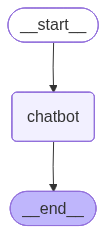

In [6]:

from IPython.display import Image, display
display(Image(app1.get_graph().draw_mermaid_png()))

In [7]:
input={"messages":["hi, my name is pragi"]}


In [8]:
app1.invoke(input)

{'messages': [HumanMessage(content='hi, my name is pragi', additional_kwargs={}, response_metadata={}, id='edf380ce-e1a5-41a2-a389-a961c6620bb2'),
  AIMessage(content="Hello Pragi, it's nice to meet you. Is there something I can help you with or would you like to chat?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 27, 'prompt_tokens': 42, 'total_tokens': 69, 'completion_time': 0.045735639, 'completion_tokens_details': None, 'prompt_time': 0.00198407, 'prompt_tokens_details': None, 'queue_time': 0.041050293, 'total_time': 0.047719709}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_ce7bc1685b', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f0a93-8905-7011-a5d8-863184020cdb-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 42, 'output_tokens': 27, 'total_tokens': 69})]}

### workflow2

In [9]:
@tool
def search(query: str):
    """this is my custom tool."""
    if "sf" in query.lower() or "san francisco" in query.lower():
        return "It's 60 degrees and foggy."
    return "It's 90 degrees and sunny."

In [10]:
search

StructuredTool(name='search', description='this is my custom tool.', args_schema=<class 'langchain_core.utils.pydantic.search'>, func=<function search at 0x000001D3D2A7AD40>)

In [11]:
tools=[search]

In [12]:
tool_node=ToolNode(tools)

In [13]:
llm_with_tool=llm.bind_tools(tools)

In [14]:
from langchain_core.messages import SystemMessage

def call_model(state: MessagesState):
    messages = state["messages"]
    
    # System message prevents the LLM looping on tool results
    system = SystemMessage(content=(
        "You are a helpful assistant. "
        "When you receive a tool result, use it to answer the user directly. "
        "Do not call the same tool again."
    ))
    
    response = llm_with_tool.invoke([system] + messages)
    return {"messages": [response]}

In [15]:
response=call_model({"messages": ["hi how are you?"]})

In [16]:
response

{'messages': [AIMessage(content="I'm doing well, thanks for asking. Is there something I can help you with or would you like to chat?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 25, 'prompt_tokens': 242, 'total_tokens': 267, 'completion_time': 0.086599782, 'completion_tokens_details': None, 'prompt_time': 0.021685605, 'prompt_tokens_details': None, 'queue_time': 0.040915822, 'total_time': 0.108285387}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_ba38bbab80', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f0a93-89c4-7ac0-b390-3c2143871c0c-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 242, 'output_tokens': 25, 'total_tokens': 267})]}

In [17]:
def router_function(state: MessagesState) -> Literal["tools", END]:
    print(f"here is a state from should continue {state}")
    messages = state['messages']
    last_message = messages[-1]
    print(f"here is a last message from should continue {last_message}")
    if last_message.tool_calls:
        return "tools"
    return END

In [18]:
workflow2 = StateGraph(MessagesState)

workflow2.add_node("agent", call_model)
workflow2.add_node("tools", tool_node)

workflow2.add_edge(START, "agent")

workflow2.add_conditional_edges("agent",router_function,{"tools": "tools", END: END})

app2 = workflow2.compile()

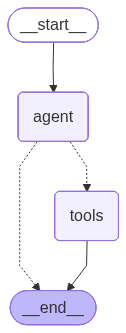

In [19]:
from IPython.display import Image, display
display(Image(app2.get_graph().draw_mermaid_png()))

In [20]:
app2.invoke({"messages": ["hi how are you?"]})

here is a state from should continue {'messages': [HumanMessage(content='hi how are you?', additional_kwargs={}, response_metadata={}, id='20a3587a-3fb3-4e01-876a-dab68ba1a322'), AIMessage(content="I'm doing well, thanks for asking. Is there something I can help you with or would you like to chat?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 25, 'prompt_tokens': 242, 'total_tokens': 267, 'completion_time': 0.075018433, 'completion_tokens_details': None, 'prompt_time': 0.01251593, 'prompt_tokens_details': None, 'queue_time': 0.041497908, 'total_time': 0.087534363}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_f8b414701e', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f0a93-8bd5-7fc2-95b5-2f9285a2f4fe-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 242, 'output_tokens': 25, 'total_tokens': 267})]}
here is a last message from should continu

{'messages': [HumanMessage(content='hi how are you?', additional_kwargs={}, response_metadata={}, id='20a3587a-3fb3-4e01-876a-dab68ba1a322'),
  AIMessage(content="I'm doing well, thanks for asking. Is there something I can help you with or would you like to chat?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 25, 'prompt_tokens': 242, 'total_tokens': 267, 'completion_time': 0.075018433, 'completion_tokens_details': None, 'prompt_time': 0.01251593, 'prompt_tokens_details': None, 'queue_time': 0.041497908, 'total_time': 0.087534363}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_f8b414701e', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f0a93-8bd5-7fc2-95b5-2f9285a2f4fe-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 242, 'output_tokens': 25, 'total_tokens': 267})]}

In [21]:
workflow2.add_edge("tools", "agent")

Adding an edge to a graph that has already been compiled. This will not be reflected in the compiled graph.


In [22]:
app2 = workflow2.compile()

In [23]:
app2.invoke({"messages": ["what is the weather in sf"]})

here is a state from should continue {'messages': [HumanMessage(content='what is the weather in sf', additional_kwargs={}, response_metadata={}, id='e891be68-5bdd-4569-a788-713af589a558'), AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'nbxktf193', 'function': {'arguments': '{"query":"San Francisco weather"}', 'name': 'search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 15, 'prompt_tokens': 243, 'total_tokens': 258, 'completion_time': 0.043475103, 'completion_tokens_details': None, 'prompt_time': 0.011932792, 'prompt_tokens_details': None, 'queue_time': 0.041681374, 'total_time': 0.055407895}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_ce7bc1685b', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f0a93-8c8a-7a41-91ec-49d23f24d3a9-0', tool_calls=[{'name': 'search', 'args': {'query': 'San Francisco weather'}, 'id': 'nbxktf193', 'type': 'tool_

{'messages': [HumanMessage(content='what is the weather in sf', additional_kwargs={}, response_metadata={}, id='e891be68-5bdd-4569-a788-713af589a558'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'nbxktf193', 'function': {'arguments': '{"query":"San Francisco weather"}', 'name': 'search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 15, 'prompt_tokens': 243, 'total_tokens': 258, 'completion_time': 0.043475103, 'completion_tokens_details': None, 'prompt_time': 0.011932792, 'prompt_tokens_details': None, 'queue_time': 0.041681374, 'total_time': 0.055407895}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_ce7bc1685b', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f0a93-8c8a-7a41-91ec-49d23f24d3a9-0', tool_calls=[{'name': 'search', 'args': {'query': 'San Francisco weather'}, 'id': 'nbxktf193', 'type': 'tool_call'}], invalid_tool_calls=[], usa

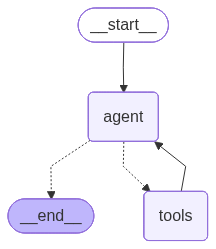

In [24]:
from IPython.display import Image, display
display(Image(app2.get_graph().draw_mermaid_png()))

### workflow 3

In [26]:
memory = MemorySaver()

In [27]:
workflow3 = StateGraph(MessagesState)

workflow3.add_node("agent", call_model)
workflow3.add_node("tools", tool_node)

workflow3.add_edge(START, "agent")

workflow3.add_conditional_edges("agent",router_function,{"tools": "tools", END: END})

workflow3.add_edge("tools", 'agent')

In [28]:
app3 = workflow3.compile(checkpointer = memory)

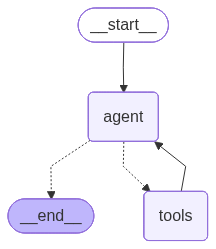

In [29]:
try:
    display(Image(app3.get_graph().draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass

In [30]:

config = {"configurable": {"thread_id": "1"}}

In [31]:
events = app3.stream(
    {"messages": ["Hi there! My name is pragi."]}, config, stream_mode="values"
)

In [32]:
for event in events:
    event["messages"][-1].pretty_print()

================================ Human Message =================================

Hi there! My name is pragi.
here is a state from should continue {'messages': [HumanMessage(content='Hi there! My name is pragi.', additional_kwargs={}, response_metadata={}, id='1ad96607-4c8b-4a5f-903c-88214c9cb729'), AIMessage(content="Hello Pragi, it's nice to meet you. Is there something I can help you with or would you like to chat?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 27, 'prompt_tokens': 246, 'total_tokens': 273, 'completion_time': 0.060577726, 'completion_tokens_details': None, 'prompt_time': 0.012692276, 'prompt_tokens_details': None, 'queue_time': 0.041299378, 'total_time': 0.073270002}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_ce7bc1685b', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f0a98-6be5-7f63-ad90-2f8be4d7337d-0', tool_calls=[], invalid_tool_calls=[], 

In [33]:
events = app3.stream(
    {"messages": ["can you tell me what was my name?"]}, config, stream_mode="values"
)

In [34]:
for event in events:
    event["messages"][-1].pretty_print()

================================ Human Message =================================

can you tell me what was my name?
here is a state from should continue {'messages': [HumanMessage(content='Hi there! My name is pragi.', additional_kwargs={}, response_metadata={}, id='1ad96607-4c8b-4a5f-903c-88214c9cb729'), AIMessage(content="Hello Pragi, it's nice to meet you. Is there something I can help you with or would you like to chat?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 27, 'prompt_tokens': 246, 'total_tokens': 273, 'completion_time': 0.060577726, 'completion_tokens_details': None, 'prompt_time': 0.012692276, 'prompt_tokens_details': None, 'queue_time': 0.041299378, 'total_time': 0.073270002}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_ce7bc1685b', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f0a98-6be5-7f63-ad90-2f8be4d7337d-0', tool_calls=[], invalid_tool_call

In [35]:
memory.get(config)

{'v': 4,
 'ts': '2026-06-27T19:39:52.845119+00:00',
 'id': '1f1725ff-7b46-68f9-8004-431ece3611dc',
 'channel_versions': {'__start__': '00000000000000000000000000000005.0.049414872823233646',
  'messages': '00000000000000000000000000000006.0.6543061310938629',
  'branch:to:agent': '00000000000000000000000000000006.0.6543061310938629'},
 'versions_seen': {'__input__': {},
  '__start__': {'__start__': '00000000000000000000000000000004.0.22562313521140098'},
  'agent': {'branch:to:agent': '00000000000000000000000000000005.0.049414872823233646'}},
 'updated_channels': ['messages'],
 'channel_values': {'messages': [HumanMessage(content='Hi there! My name is pragi.', additional_kwargs={}, response_metadata={}, id='1ad96607-4c8b-4a5f-903c-88214c9cb729'),
   AIMessage(content="Hello Pragi, it's nice to meet you. Is there something I can help you with or would you like to chat?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 27, 'prompt_tokens': 246, 'total_tokens